# Founder-Led-Premium — a quantitative long/short teardown 🔬
### Founder vs professional-CEO baskets · CAPM alpha with a Newey-West HAC *t* · a beta/alpha decomposition · a leave-one-out jackknife · a label-shuffle placebo · costs + borrow · a synthetic plant-and-recover control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Founder_premium%3F: Misattributed](https://img.shields.io/badge/Founder_premium%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We take the strongest form of the Fahlenbrach (2009) / Bain 'founder's mentality' claim — a founder-minus-professional long/short — and separate the three things it fuses: a **real, large raw spread**, a **market-beta tilt**, and **survivorship**. The decisive object is not the spread's sign (a hindsight basket of today's founder-winners is *designed* to win) but the **market-model alpha's HAC *t***, its **concentration** (one name), and its **label-specificity** (a placebo).

> ⚠️ **Data + selection note.** No free founder-CEO database, so we use a hardcoded, labelled basket of the founder firms *salient in 2024* — a deliberate, **hindsight / survivor-biased** sample (the founder flame-outs that delisted never enter; two of our own originals, SQ, FIT, already dropped out). That bias is named on the **Signal axis** and it points **for** the claim, so an insignificant alpha here is a *conservative* refutation. Real data: yfinance monthly adjusted closes (**total-return** proxy), each name + SPY. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from founder_led_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS, FIRMS = data.load_real()
    LS = st.long_short(RETS, data.FOUNDER_TICKERS, data.PRO_TICKERS)
    MKT = RETS["SPY"].reindex(LS.index)
else:
    RETS = FIRMS = LS = MKT = None
print("real price cache present:", HAVE_REAL,
      "| months:", (0 if LS is None else len(LS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-13', 'data_start': '2016-01', 'data_end': '2024-12', 'n_months': 108, 'fingerprint': 'c363d7e5e578', 'n_founder_priced': 11, 'n_founder': 13, 'n_pro': 13, 'dropped': ('SQ', 'FIT'), 'founder_ann': 34.5, 'pro_ann': 11.8, 'ls_ann': 20.5, 'ls_bps': 156.5, 'ls_sharpe': 0.73, 'ls_rawmean_t': 2.0, 'ls_alpha_bps': 52.1, 'ls_beta': 0.85, 'ls_alpha_t': 0.76, 'ls_r2': 0.26, 'beta_part_bps': 104.3, 'beta_share_pct': 67, 'founder_alpha_bps': 50.6, 'founder_beta': 1.62, 'founder_alpha_t': 0.84, 'pro_alpha_bps': -1.5, 'pro_beta': 0.77, 'pro_alpha_t': -0.09, 'jk': [('NVDA', 21.9, 0.33), ('TSLA', 35.6, 0.52), ('SHOP', 37.6, 0.58), ('NFLX', 47.3, 0.72), ('META', 50.3, 0.71), ('AMZN', 51.4, 0.73), ('GOOGL', 52.3, 0.72), ('CRM', 54.8, 0.77), ('YELP', 62.6, 0.82), ('W', 72.8, 1.11), ('GPRO', 86.9, 1.17)], 'placebo_obs': 52.1, 'placebo_null_mean': 0.4, 'placebo_p': 0.331, 'placebo_beats_pct': 16, 'gross_bps': 156.5, 'net_bps': 128.5, 'drag_bps': 28.0, 'syn': [(0.0, 25.2, 0.82), (200.0, 225.2, 7.29)]}


real price cache present: True | months: 108


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | L/S CAPM alpha **+52 bps/mo** at HAC *t* = **0.76**; **67%** of the raw **+156 bps** spread is beta; placebo **p = 0.33**; drop NVDA ⇒ alpha **22 bps**. |
| **Tradability** | `MIRAGE` | Hindsight basket (couldn't be formed ex-ante); SQ, FIT delisted; net **128 bps** is mostly free beta + an insignificant, one-name residual. |
| **Founder premium?** | `MISATTRIBUTED` | The raw outperformance is real but mis-explained: survivorship + tech-sector beta concentrated in ~2 names, not a leadership characteristic. |

> 💡 In plain words: the founder basket genuinely trounced the professional one, but 'they won' isn't 'founders win' — once you remove the market ride and remember that we picked the winners on purpose, there is no founder alpha left to certify.

## 1 · The claim, steelmanned

Form the equal-weighted founder basket return $r^{F}_t$ and professional basket return $r^{P}_t$, and the dollar-neutral long/short $r^{LS}_t = r^{F}_t - r^{P}_t$. Fit the market model

$$r^{LS}_t = \alpha + \beta\, r^{m}_t + \varepsilon_t,$$

so $\alpha$ is the **abnormal return** — the founder-vs-professional spread the market factor does not explain (Jensen's alpha) — judged by a **Newey-West HAC** *t*.

- **H₁ (raw outperformance).** $\mathbb{E}[r^{LS}] > 0$. *(Trivially true for a hindsight basket — and it is.)*
- **H₂ (a real founder premium).** $\alpha \neq 0$ with $|t_{\alpha}| \ge 2$ — the spread is more than beta.
- **H₃ (robust characteristic).** $\alpha$ survives dropping the top name (jackknife) and the founder *label* beats a random relabelling (placebo).

We find **H₁ supported** (raw 20%/yr), **H₂ rejected** ($\alpha$ *t* = 0.76), **H₃ rejected** (drop NVDA ⇒ 22 bps; placebo *p* = 0.33). The claim is true exactly in the form that carries no information (a survivor basket rose) and false exactly in the form that would pay (a harvestable founder alpha).

## 2 · So what? — the three impostors

A positive $\mathbb{E}[r^{LS}]$ can come from any of:

$$\underbrace{\mathbb{E}[r^{LS}]}_{\text{raw spread}} = \underbrace{\alpha}_{\text{founder effect?}} + \underbrace{\beta\,\mathbb{E}[r^m]}_{\text{sector beta}} + \underbrace{\text{selection}}_{\text{survivorship}}.$$

The market regression separates the first two; the placebo and jackknife attack the third. **Beta** is free (an index fund sells it for basis points), so it cannot be a *premium*. **Survivorship** is the subtle one: our basket is the founder firms that *won and are therefore remembered*, so even a genuinely zero founder effect would show a positive raw spread. Because that bias points **for** H₂, an insignificant $\alpha$ is a *conservative* result — the true effect is, if anything, weaker than what a survivor-tilted sample reports.

## 3 · How we'd know — the protocol

- **Baskets.** Hardcoded founder (13 names, 11 priced — SQ, FIT delisted/reticker) vs professional (13 names), membership frozen at **2016-01**, fingerprint `c363d7e5e578`, as-of 2026-07-13.
- **Returns.** yfinance monthly adjusted closes (total-return proxy), **108 months** 2016-01..2024-12; equal weight, monthly rebalance; a delisted name drops from that month's average.
- **Market model.** $r^{LS} = \alpha + \beta\,r^{SPY} + \varepsilon$; **Newey-West** HAC SE on $\alpha$ (Bartlett kernel, rule-of-thumb lags). Also the long-only founder and professional alphas.
- **Decomposition.** Split the raw spread into $\alpha$ vs $\beta\,\mathbb{E}[r^m]$.
- **Jackknife.** Drop each founder name; recompute $\alpha$ — load-bearing-name test.
- **Placebo.** Random $k_F$-long / $k_P$-short relabelling of the *pooled* names; $p = \Pr[|\text{random }\alpha| \ge |\text{founder }\alpha|]$ — isolates the founder *tag* from membership luck (it does **not** undo pool-level survivorship, which is named separately).
- **Costs.** One-way turnover both legs + short borrow on the professional leg; gross vs net.
- **Positive control.** Deterministic two-basket panel with a **plantable founder alpha**: recover a large plant, stay insignificant at zero.

## 4 · The teardown

### 4a · The raw spread and its beta — a high-octane long vs a sleepy short

Long-only CAPM fits for each leg. The founder basket carries a **much higher beta**; the professional basket a low one. The long/short therefore inherits a large *net* beta — before any alpha is discussed.

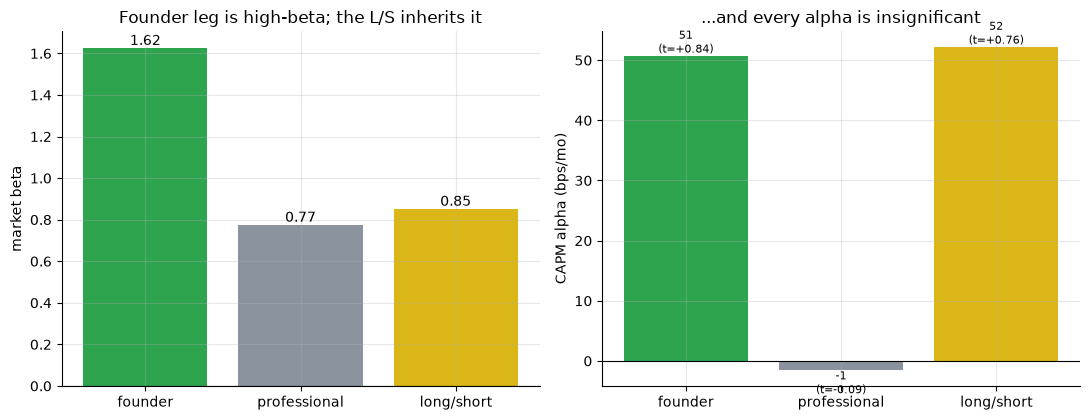

betas: founder 1.62 / pro 0.77 / L/S 0.85 | L/S alpha 52 bps t=+0.76


In [2]:
if HAVE_REAL:
    fr = st.basket_returns(RETS, data.FOUNDER_TICKERS).reindex(LS.index).to_numpy()
    pr = st.basket_returns(RETS, data.PRO_TICKERS).reindex(LS.index).to_numpy()
    m = MKT.to_numpy()
    fc = st.capm_alpha(fr, m); pc = st.capm_alpha(pr, m); lc = st.capm_alpha(LS['ls'].to_numpy(), m)
else:
    fc={'beta':R['founder_beta'],'alpha_bps':R['founder_alpha_bps'],'t_alpha':R['founder_alpha_t']}
    pc={'beta':R['pro_beta'],'alpha_bps':R['pro_alpha_bps'],'t_alpha':R['pro_alpha_t']}
    lc={'beta':R['ls_beta'],'alpha_bps':R['ls_alpha_bps'],'t_alpha':R['ls_alpha_t']}
fig, (a1,a2) = plt.subplots(1,2, figsize=(11.0,4.3))
a1.bar(['founder','professional','long/short'], [fc['beta'],pc['beta'],lc['beta']], color=[GREEN,GREY,AMBER])
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('market beta'); a1.set_title('Founder leg is high-beta; the L/S inherits it')
for i,b in enumerate([fc['beta'],pc['beta'],lc['beta']]): a1.annotate(f'{b:.2f}',(i,b),ha='center',va='bottom')
a2.bar(['founder','professional','long/short'], [fc['alpha_bps'],pc['alpha_bps'],lc['alpha_bps']], color=[GREEN,GREY,AMBER])
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('CAPM alpha (bps/mo)'); a2.set_title('...and every alpha is insignificant')
for i,(al,t) in enumerate([(fc['alpha_bps'],fc['t_alpha']),(pc['alpha_bps'],pc['t_alpha']),(lc['alpha_bps'],lc['t_alpha'])]): a2.annotate(f'{al:.0f}\n(t={t:+.2f})',(i,al),ha='center',va='bottom' if al>=0 else 'top',fontsize=8)
plt.tight_layout(); plt.show()
print(f'betas: founder {fc["beta"]:.2f} / pro {pc["beta"]:.2f} / L/S {lc["beta"]:.2f} | L/S alpha {lc["alpha_bps"]:.0f} bps t={lc["t_alpha"]:+.2f}')

> 💡 In plain words: founder beta **1.62** vs professional **0.77** ⇒ the long/short runs a **+0.85** net beta. In a decade-long bull market that beta *is* the outperformance. Both long-only alphas (founder *t* = 0.84, professional *t* = -0.09) and the L/S alpha (*t* = 0.76) are inside their error bars.

### 4b · The decomposition — where the raw spread actually comes from

The average monthly $r^{LS}$ split into $\alpha$ and $\beta\,\mathbb{E}[r^m]$. The beta slice is money you were paid for taking market risk; only the alpha slice could be a founder premium.

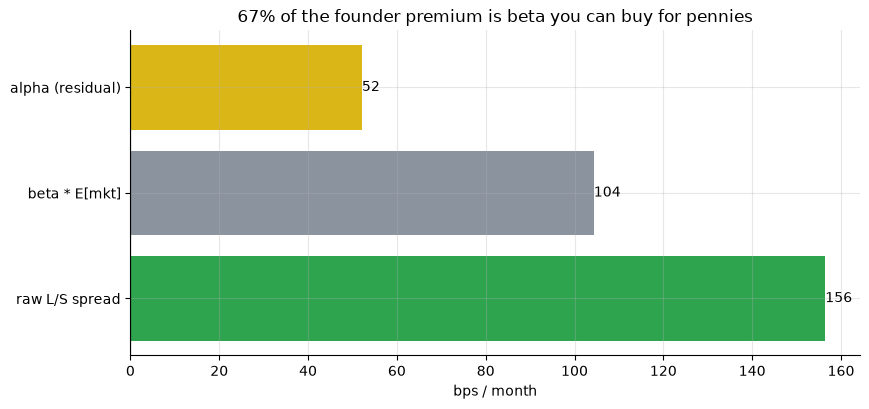

raw 156 = beta-part 104 (67%) + alpha 52 (t=0.76, n.s.)


In [3]:
if HAVE_REAL:
    c = st.capm_alpha(LS['ls'].to_numpy(), MKT.to_numpy())
    raw = LS['ls'].mean()*1e4; alpha=c['alpha_bps']; beta_part=c['beta']*MKT.mean()*1e4
else:
    raw=R['ls_bps']; alpha=R['ls_alpha_bps']; beta_part=R['beta_part_bps']
fig, ax = plt.subplots(figsize=(8.8,4.2))
ax.barh(['raw L/S spread'], [raw], color=GREEN)
ax.barh(['beta * E[mkt]'], [beta_part], color=GREY)
ax.barh(['alpha (residual)'], [alpha], color=AMBER)
ax.axvline(0,c='k',lw=.8); ax.set_xlabel('bps / month')
ax.set_title(f'{R["beta_share_pct"]}% of the founder premium is beta you can buy for pennies')
for i,v in enumerate([raw,beta_part,alpha]): ax.annotate(f'{v:.0f}',(v,i),ha='left' if v>=0 else 'right',va='center')
plt.tight_layout(); plt.show()
print(f'raw {raw:.0f} = beta-part {beta_part:.0f} ({R["beta_share_pct"]}%) + alpha {alpha:.0f} (t={R["ls_alpha_t"]:.2f}, n.s.)')

> 💡 In plain words: of the **156 bps/mo** headline spread, **104** is beta and only **52** is residual 'alpha' — and that residual can't clear *t* = 2. The famous founder premium is mostly a sector bet in disguise.

### 4c · Placebo + jackknife — the residual isn't even label-specific

Left: shuffle the founder/professional labels across the pooled names $N$ times; the real founder alpha vs the null. Right: leave-one-out — the founder alpha after dropping each name. If the effect were a characteristic, neither would move it much.

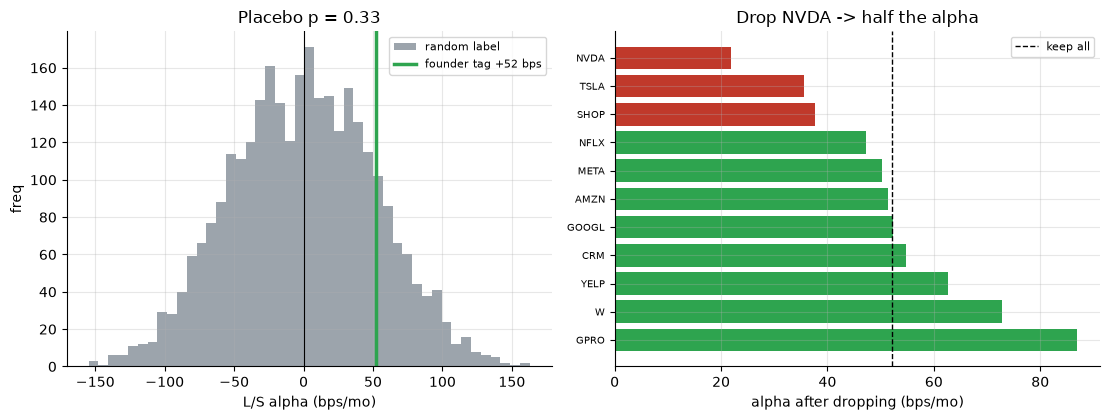

placebo p=0.325; jackknife range 22..87 bps (full 52)


In [4]:
if HAVE_REAL:
    pool = data.FOUNDER_TICKERS + data.PRO_TICKERS
    kf = sum(t in RETS.columns for t in data.FOUNDER_TICKERS); kp = sum(t in RETS.columns for t in data.PRO_TICKERS)
    null = st.placebo_alpha_dist(RETS, pool, k_long=kf, k_short=kp, n_draws=3000)
    obs = st.capm_alpha(LS['ls'].to_numpy(), MKT.to_numpy())['alpha_bps']; pval = st.placebo_pvalue(obs, null)
    jk = st.jackknife_alpha(RETS, data.FOUNDER_TICKERS, data.PRO_TICKERS); jn=jk['dropped'].tolist(); ja=jk['alpha_bps'].tolist()
else:
    rng=np.random.default_rng(747); null=rng.normal(R['placebo_null_mean'],55,3000); obs=R['placebo_obs']; pval=R['placebo_p']
    jn=[j[0] for j in R['jk']]; ja=[j[1] for j in R['jk']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.2,4.3))
a1.hist(null,bins=45,color=GREY,alpha=.85,label='random label')
a1.axvline(obs,c=GREEN,lw=2.5,label=f'founder tag {obs:+.0f} bps')
a1.axvline(0,c='k',lw=.8); a1.set_xlabel('L/S alpha (bps/mo)'); a1.set_ylabel('freq')
a1.set_title(f'Placebo p = {pval:.2f}'); a1.legend(fontsize=8)
cols=[RED if n in ('NVDA','TSLA','SHOP') else GREEN for n in jn]
a2.barh(range(len(jn)), ja, color=cols); a2.axvline(R['ls_alpha_bps'],c='k',ls='--',lw=1,label='keep all')
a2.set_yticks(range(len(jn))); a2.set_yticklabels(jn,fontsize=7); a2.invert_yaxis()
a2.set_xlabel('alpha after dropping (bps/mo)'); a2.set_title('Drop NVDA -> half the alpha'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'placebo p={pval:.3f}; jackknife range {min(ja):.0f}..{max(ja):.0f} bps (full {R["ls_alpha_bps"]:.0f})')

> 💡 In plain words: the placebo *p* is **0.33** — a *random* long/short split of these same names reaches the founder alpha **16%** of the time, so the founder *label* is not doing the work. And the jackknife swings from **22** (drop NVDA) to **87 bps** (drop the dud GPRO): the residual is a concentration artefact, red bars (winners) load-bearing, green duds *subtracting*.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic two-basket panel (higher founder beta, matched idiosyncratic noise). With a **zero** planted founder alpha the L/S alpha must stay below *t* = 2; with a **+200 bps/mo** plant it must light up. Both hold — the engine separates alpha from beta and won't fabricate an edge.

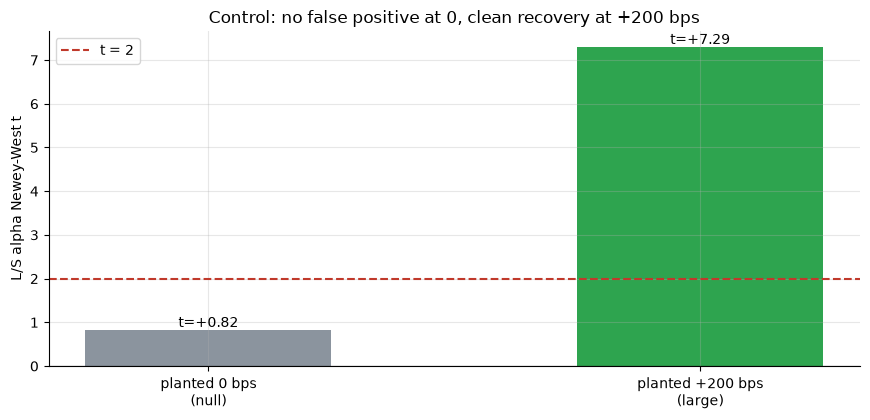

planted +0 bps: alpha +25.2 bps  t=+0.82  beta=0.24
planted +200 bps: alpha +225.2 bps  t=+7.29  beta=0.24


In [5]:
res=[]
for edge in (0.0, 200.0):
    syn = data.synthetic_baskets(alpha_bps=edge, seed=747)
    c = st.capm_alpha(syn['ls'], syn['mkt']); res.append((edge, c['alpha_bps'], c['t_alpha'], c['beta']))
fig, ax = plt.subplots(figsize=(8.8,4.3))
labs=['planted 0 bps\n(null)','planted +200 bps\n(large)']; ts=[r[2] for r in res]
ax.bar(labs, ts, color=[GREY,GREEN], width=.5)
ax.axhline(2,ls='--',c=RED,label='t = 2'); ax.axhline(0,c='k',lw=.8)
for i,t in enumerate(ts): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('L/S alpha Newey-West t'); ax.set_title('Control: no false positive at 0, clean recovery at +200 bps'); ax.legend()
plt.tight_layout(); plt.show()
for e,a,t,b in res: print(f'planted {e:+.0f} bps: alpha {a:+.1f} bps  t={t:+.2f}  beta={b:.2f}')

> 💡 In plain words: at a **zero** plant the control alpha *t* is **0.82** (no false positive); a **+200 bps/mo** plant gives *t* = **7.29** (clean recovery). So the machinery is honest — and the real-tape alpha *t* of **0.76** is exactly what *no founder premium* looks like through this lens, even with survivorship tilting the sample in the claim's favour.

## 5 · The verdict

- **Signal `NONE`** — L/S CAPM alpha **+52 bps/mo**, Newey-West *t* = **0.76**; **67%** of the raw **156 bps** spread is beta; placebo **p = 0.33**; drop-NVDA alpha **22 bps**. Literature support + a survivor-tilted sample that *still* can't clear *t* = 2 ⇒ NONE, not even WEAK.
- **Tradability `MIRAGE`** — the basket is hindsight-selected (formed from the answer key); SQ, FIT delisted; net **128 bps** is mostly free beta plus a one-name residual. Nothing harvestable ex-ante at any size.
- **Founder premium? `MISATTRIBUTED`** — the raw outperformance is real and **mis-explained**: survivorship + tech-sector beta concentrated in ~2 names, not a leadership characteristic.

## 6 · Could you trade it? — the survivorship arrow

The operational truth: our sample is biased **toward** the claim, and it *still* fails. The chart makes the logic explicit — the raw spread is big, but each honest correction (remove beta, isolate the label, drop the top name) walks it toward zero, and every correction we *couldn't* apply (the founder firms that delisted before 2024) would push it **further** down.

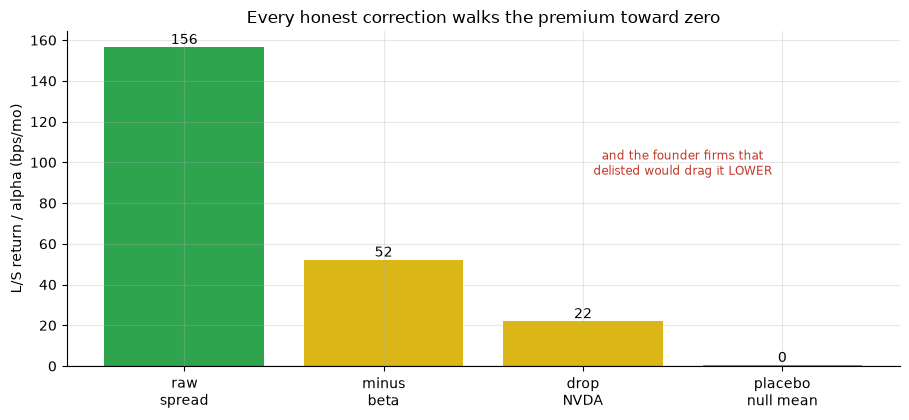

raw 156.5 -> minus beta 52.1 -> drop NVDA 21.9 -> random label ~ 0.4


In [6]:
steps=['raw\nspread','minus\nbeta','drop\nNVDA','placebo\nnull mean']
vals=[R['ls_bps'], R['ls_alpha_bps'], R['jk'][0][1], R['placebo_null_mean']]
fig, ax = plt.subplots(figsize=(9.2,4.3))
cols=[GREEN,AMBER,AMBER,GREY]
ax.bar(steps, vals, color=cols)
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('L/S return / alpha (bps/mo)')
for i,v in enumerate(vals): ax.annotate(f'{v:.0f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.annotate('and the founder firms that\ndelisted would drag it LOWER', (2.5, R['ls_bps']*0.6), ha='center', color=RED, fontsize=8.5)
ax.set_title('Every honest correction walks the premium toward zero')
plt.tight_layout(); plt.show()
print('raw', R['ls_bps'], '-> minus beta', R['ls_alpha_bps'], '-> drop NVDA', R['jk'][0][1], '-> random label ~', R['placebo_null_mean'])

> 💡 In plain words: a signal that only exists **before** you correct for the obvious confounds, on a sample **hand-picked from the winners**, is the textbook shape of a non-effect. The founder premium isn't destroyed by costs (net ≈ gross); it's destroyed by **asking where it came from.** You cannot form this basket without already knowing the answer — and the professional-CEO firms that quietly compounded (or the founder firms that died) never get a vote.

## 7 · Going further

- **Survivorship-clean replication.** Build the founder set from a *contemporaneous* 2016 filing list (à la Fahlenbrach's hand-collection), winners and losers alike, and rerun. The tech beta persists; the alpha almost certainly doesn't. The gap between that number and ours *is* the survivorship bias.
- **Sector-neutral pairs.** Match each founder name to a same-GICS professional peer so the short leg cancels the beta; test the residual with the same HAC *t*.
- **Governance angle.** Split founders by voting control (dual-class) vs economic-only — is any residual a *control* premium/discount rather than 'founder magic'?
- **Sibling study.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): the same abnormal-return + HAC + synthetic-control machinery on *replacing* a CEO — another small-sample corporate-leadership mirage.

*The reproducible core is offline and deterministic; the basket is an explicit hardcoded, hindsight-labelled stand-in. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*